
# Прогнозирование конверсии посетителей интернет-магазина в покупателей

**Бизнес-задача:** по данным о сессии посетителя интернет-магазина предсказать, завершится ли визит покупкой (`Revenue = 1`) или нет (`Revenue = 0`).

---

## Что будет в ноутбуке

1. Проверка качества данных и краткое описание датасета  
2. Разведывательный анализ данных (EDA) и поиск факторов конверсии  
3. Предобработка признаков: масштабирование числовых признаков + one-hot-encoding категориальных  
4. Сравнение моделей `Dummy`, `RandomForest` и `XGBoost`  
5. Компактный тюнинг `XGBoost`  
6. Финальная оценка на holdout-test и бизнес-выводы  


## 1. Импорт библиотек и настройка окружения


In [2]:

import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    roc_curve,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 130

print("Environment is ready.")


Environment is ready.



## 2. Загрузка данных


In [3]:

DATA_PATH = "online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)
df["Revenue"] = df["Revenue"].astype(int)

display(df.head())

profile = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "missing values",
        "duplicate rows",
        "conversion rate",
        "buyers",
        "non-buyers"
    ],
    "value": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        f"{df['Revenue'].mean():.2%}",
        int(df["Revenue"].sum()),
        int((1 - df["Revenue"]).sum())
    ]
})

display(profile)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


,metric,value
0,rows,12330
1,columns,18
2,missing values,0
3,duplicate rows,125
4,conversion rate,15.47%
5,buyers,1908
6,non-buyers,10422



### Справочник признаков

Ниже — краткая структура признаков.


In [4]:

feature_dict = pd.DataFrame([
    ["Administrative", "числовой (дискретный)", "Количество просмотренных административных страниц"],
    ["Administrative_Duration", "числовой (непрерывный)", "Время на административных страницах"],
    ["Informational", "числовой (дискретный)", "Количество информационных страниц"],
    ["Informational_Duration", "числовой (непрерывный)", "Время на информационных страницах"],
    ["ProductRelated", "числовой (дискретный)", "Количество товарных страниц"],
    ["ProductRelated_Duration", "числовой (непрерывный)", "Время на товарных страницах"],
    ["BounceRates", "числовой (непрерывный)", "Показатель отказов"],
    ["ExitRates", "числовой (непрерывный)", "Показатель выхода"],
    ["PageValues", "числовой (непрерывный)", "Ценность страницы до конверсии"],
    ["SpecialDay", "числовой", "Близость к особому дню"],
    ["Month", "категориальный", "Месяц визита"],
    ["OperatingSystems", "категориальный", "Операционная система"],
    ["Browser", "категориальный", "Тип браузера"],
    ["Region", "категориальный", "Регион"],
    ["TrafficType", "категориальный", "Тип трафика"],
    ["VisitorType", "категориальный", "Тип посетителя"],
    ["Weekend", "категориальный / bool", "Сессия пришлась на выходные или нет"],
    ["Revenue", "целевая переменная", "Совершил ли посетитель покупку"]
], columns=["feature", "type", "description"])

display(feature_dict)


,feature,type,description
0,Administrative,числовой (дискретный),Количество просмотренных административных страниц
1,Administrative_Duration,числовой (непрерывный),Время на административных страницах
2,Informational,числовой (дискретный),Количество информационных страниц
3,Informational_Duration,числовой (непрерывный),Время на информационных страницах
4,ProductRelated,числовой (дискретный),Количество товарных страниц
5,ProductRelated_Duration,числовой (непрерывный),Время на товарных страницах
6,BounceRates,числовой (непрерывный),Показатель отказов
7,ExitRates,числовой (непрерывный),Показатель выхода
8,PageValues,числовой (непрерывный),Ценность страницы до конверсии
9,SpecialDay,числовой,Близость к особому дню



## 3. Проверка качества данных

Сначала убедимся, что структура данных понятна и пригодна для моделирования.


In [5]:

quality = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(3).values
})

display(quality)

print(f"Exact duplicate rows: {df.duplicated().sum()} ({df.duplicated().mean():.2%} of the dataset)")
print(f"Overall conversion rate: {df['Revenue'].mean():.2%}")


,feature,dtype,missing,missing_pct
0,Administrative,int64,0,0.0
1,Administrative_Duration,float64,0,0.0
2,Informational,int64,0,0.0
3,Informational_Duration,float64,0,0.0
4,ProductRelated,int64,0,0.0
5,ProductRelated_Duration,float64,0,0.0
6,BounceRates,float64,0,0.0
7,ExitRates,float64,0,0.0
8,PageValues,float64,0,0.0
9,SpecialDay,float64,0,0.0


Exact duplicate rows: 125 (1.01% of the dataset)
Overall conversion rate: 15.47%



### Несбалансированность классов

Датасет несбалансирован: покупателей заметно меньше, чем непокупателей.  
Поэтому `Accuracy` может вводить в заблуждение, а основной метрикой логично сделать **ROC AUC**.


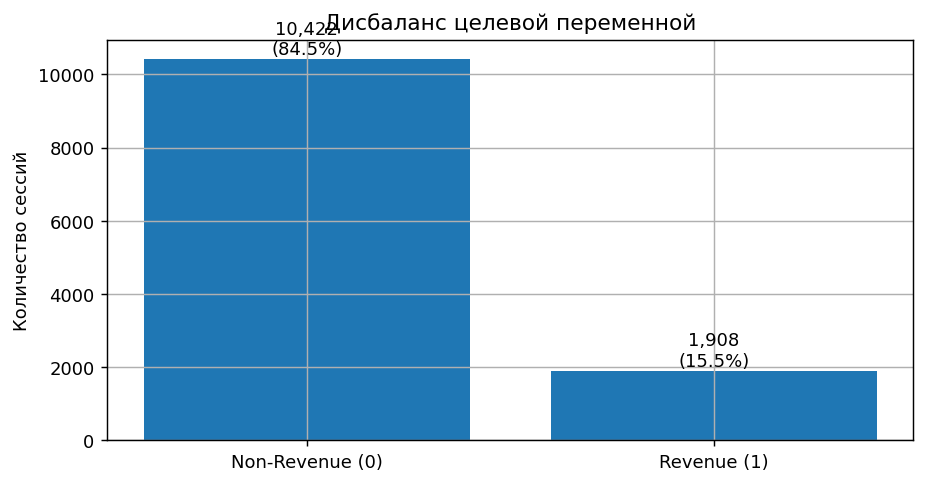

Если всегда предсказывать только класс большинства, accuracy будет ≈ 84.53%, но ROC AUC останется 0.50.


In [6]:

class_counts = df["Revenue"].value_counts().sort_index()
class_share = df["Revenue"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Non-Revenue (0)", "Revenue (1)"], class_counts.values)
ax.set_title("Дисбаланс целевой переменной")
ax.set_ylabel("Количество сессий")
for i, (cnt, share) in enumerate(zip(class_counts.values, class_share.values)):
    ax.text(i, cnt + 120, f"{cnt:,}\n({share:.1%})", ha="center")
plt.show()

majority_accuracy = max(class_share)
print(f"Если всегда предсказывать только класс большинства, accuracy будет ≈ {majority_accuracy:.2%}, но ROC AUC останется 0.50.")



## 4. Разведывательный анализ данных (EDA)

В этой части мы проверяем ключевые гипотезы:

- чем больше глубина просмотра товарных страниц, тем выше конверсия;
- высокие `ExitRates` и `BounceRates` связаны с низкой конверсией;
- `Month`, `VisitorType` и `Weekend` дают заметные сдвиги по conversion rate;
- не все категориальные признаки одинаково полезны.


In [7]:

overall_conversion = df["Revenue"].mean()

def plot_rate_by_category(data, col, title, order=None, top_n=None, rotation=0, sort_by_rate=False):
    tmp = data[[col, "Revenue"]].copy()
    counts = tmp[col].value_counts()

    if top_n is not None:
        keep = counts.head(top_n).index
        tmp = tmp[tmp[col].isin(keep)]

    summary = (
        tmp.groupby(col, observed=True)["Revenue"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "conversion_rate", "count": "sessions"})
    )

    if order is not None:
        summary = summary.reindex(order).dropna()
    elif sort_by_rate:
        summary = summary.sort_values("conversion_rate", ascending=False)

    summary = summary.reset_index()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(summary[col].astype(str), summary["conversion_rate"])
    ax.axhline(overall_conversion, linestyle="--", label=f"Средняя конверсия = {overall_conversion:.1%}")
    ax.set_title(title)
    ax.set_ylabel("Conversion rate")
    ax.tick_params(axis="x", rotation=rotation)

    for i, row in summary.iterrows():
        ax.text(
            i,
            row["conversion_rate"] + 0.003,
            f"{row['conversion_rate']:.1%}\n(n={int(row['sessions'])})",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.legend()
    plt.show()
    display(summary.round(4))
    return summary

def plot_rate_by_bins(data, col, bins, labels, title, rotation=0):
    tmp = data[[col, "Revenue"]].copy()
    tmp["bucket"] = pd.cut(
        tmp[col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        duplicates="drop"
    )

    summary = (
        tmp.groupby("bucket", observed=True)["Revenue"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "conversion_rate", "count": "sessions"})
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(summary["bucket"].astype(str), summary["conversion_rate"])
    ax.axhline(overall_conversion, linestyle="--", label=f"Средняя конверсия = {overall_conversion:.1%}")
    ax.set_title(title)
    ax.set_ylabel("Conversion rate")
    ax.tick_params(axis="x", rotation=rotation)

    for i, row in summary.iterrows():
        ax.text(
            i,
            row["conversion_rate"] + 0.003,
            f"{row['conversion_rate']:.1%}\n(n={int(row['sessions'])})",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.legend()
    plt.show()
    display(summary.round(4))
    return summary



### 4.1. Корреляции числовых признаков


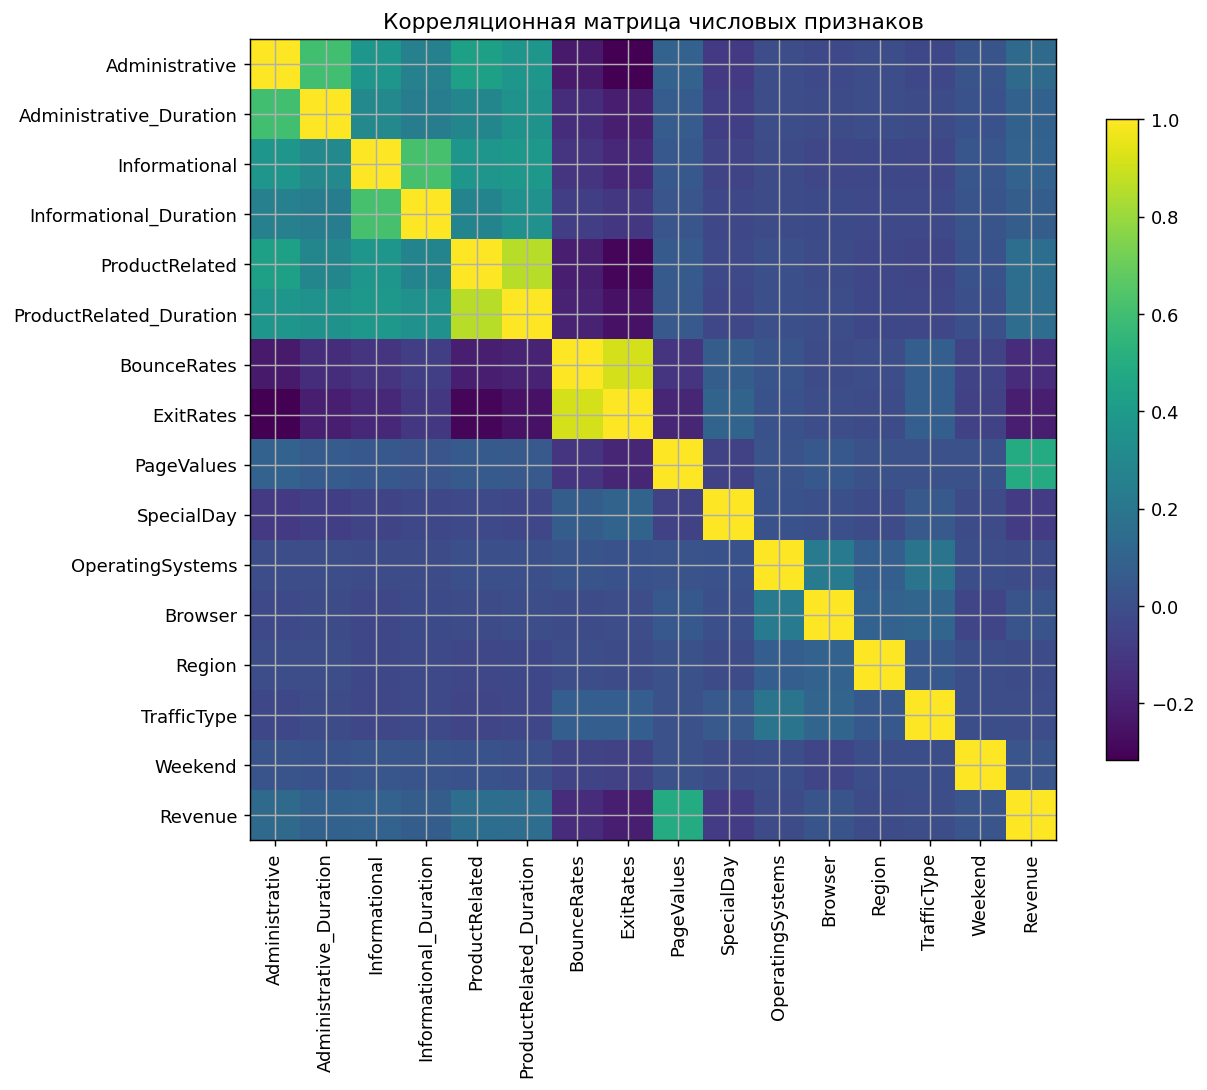

,corr_with_revenue
ExitRates,-0.207
BounceRates,-0.151
SpecialDay,-0.082
OperatingSystems,-0.015
Region,-0.012
TrafficType,-0.005
Browser,0.024
Weekend,0.029
Informational_Duration,0.070
Administrative_Duration,0.094


In [8]:

corr_frame = df.copy()
corr_frame["Weekend"] = corr_frame["Weekend"].astype(int)

corr = corr_frame.select_dtypes(include=["int64", "float64"]).corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Корреляционная матрица числовых признаков")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()

target_corr = corr["Revenue"].drop("Revenue").sort_values()
display(target_corr.to_frame("corr_with_revenue").round(3))



### 4.2. Глубина просмотра товарных страниц


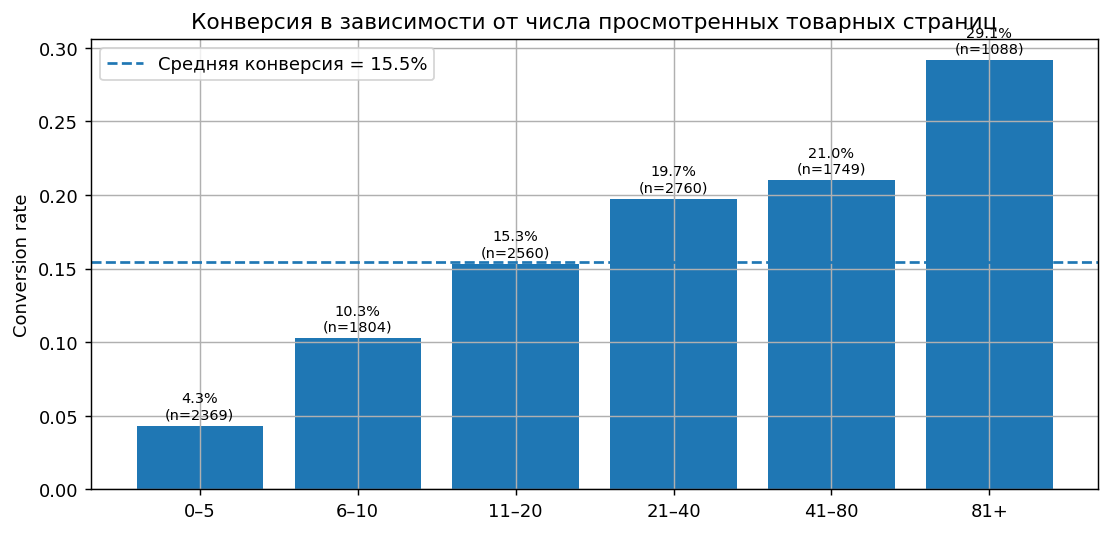

,bucket,conversion_rate,sessions
0,0–5,0.0431,2369
1,6–10,0.1025,1804
2,11–20,0.1531,2560
3,21–40,0.1975,2760
4,41–80,0.2098,1749
5,81+,0.2914,1088


In [9]:

product_pages_summary = plot_rate_by_bins(
    df,
    col="ProductRelated",
    bins=[-0.1, 5, 10, 20, 40, 80, np.inf],
    labels=["0–5", "6–10", "11–20", "21–40", "41–80", "81+"],
    title="Конверсия в зависимости от числа просмотренных товарных страниц"
)



### 4.3. Время на товарных страницах


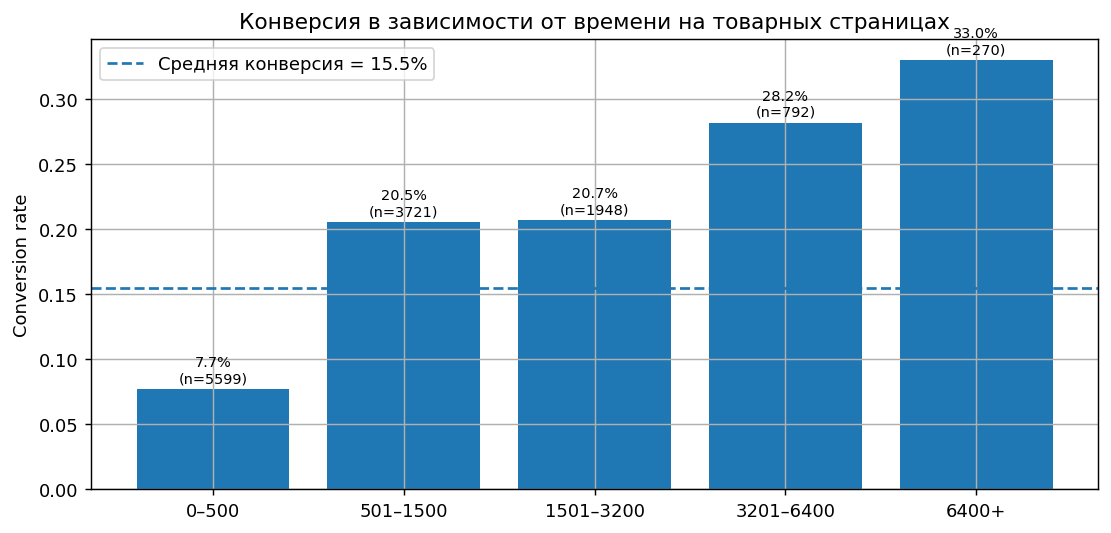

,bucket,conversion_rate,sessions
0,0–500,0.0768,5599
1,501–1500,0.2051,3721
2,1501–3200,0.2069,1948
3,3201–6400,0.2816,792
4,6400+,0.3296,270


In [10]:

product_duration_summary = plot_rate_by_bins(
    df,
    col="ProductRelated_Duration",
    bins=[-0.1, 500, 1500, 3200, 6400, np.inf],
    labels=["0–500", "501–1500", "1501–3200", "3201–6400", "6400+"],
    title="Конверсия в зависимости от времени на товарных страницах"
)



### 4.4. Exit Rate и Bounce Rate


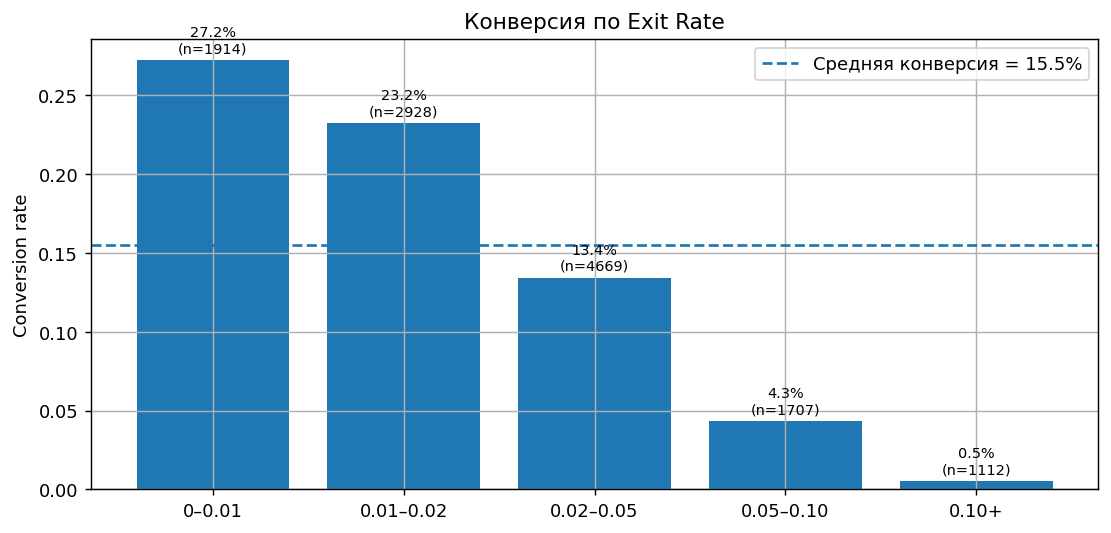

,bucket,conversion_rate,sessions
0,0–0.01,0.2722,1914
1,0.01–0.02,0.2322,2928
2,0.02–0.05,0.1343,4669
3,0.05–0.10,0.0434,1707
4,0.10+,0.0054,1112


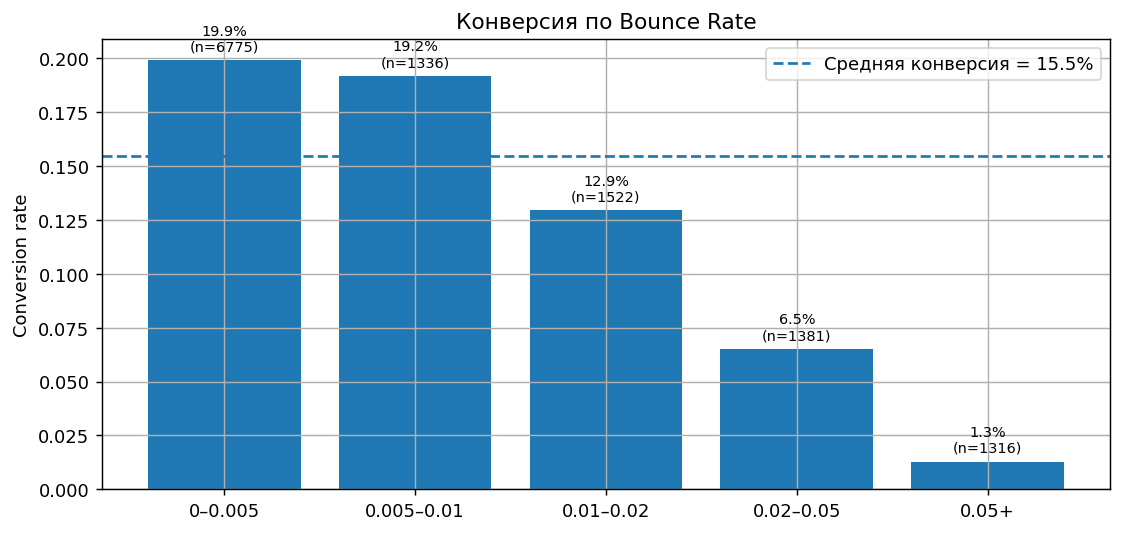

,bucket,conversion_rate,sessions
0,0–0.005,0.1990,6775
1,0.005–0.01,0.1916,1336
2,0.01–0.02,0.1294,1522
3,0.02–0.05,0.0652,1381
4,0.05+,0.0129,1316


In [11]:

exit_summary = plot_rate_by_bins(
    df,
    col="ExitRates",
    bins=[-0.0001, 0.01, 0.02, 0.05, 0.10, np.inf],
    labels=["0–0.01", "0.01–0.02", "0.02–0.05", "0.05–0.10", "0.10+"],
    title="Конверсия по Exit Rate"
)

bounce_summary = plot_rate_by_bins(
    df,
    col="BounceRates",
    bins=[-0.0001, 0.005, 0.01, 0.02, 0.05, np.inf],
    labels=["0–0.005", "0.005–0.01", "0.01–0.02", "0.02–0.05", "0.05+"],
    title="Конверсия по Bounce Rate"
)



### 4.5. Ценность страницы (`PageValues`)


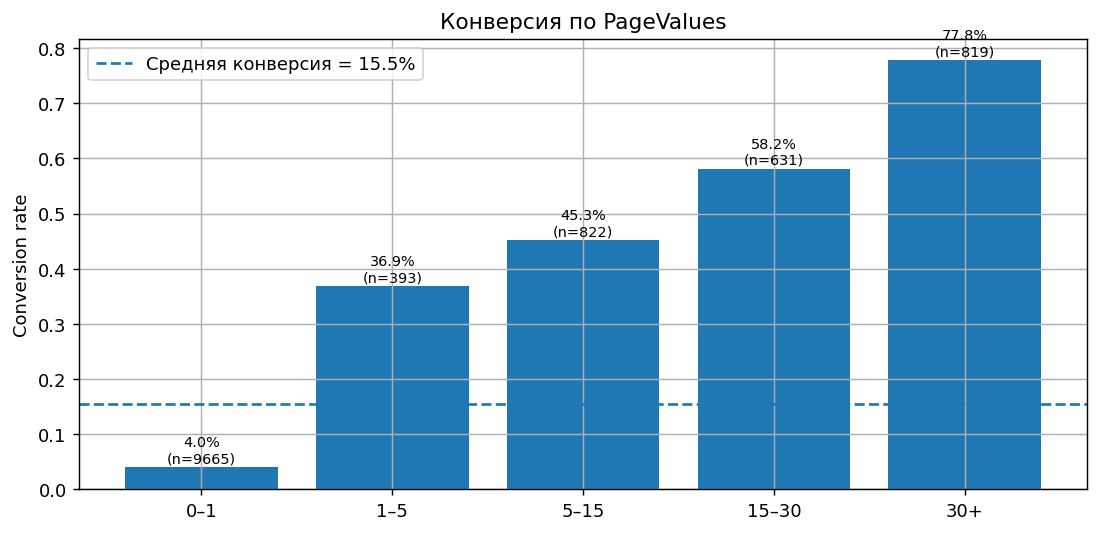

,bucket,conversion_rate,sessions
0,0–1,0.0400,9665
1,1–5,0.3690,393
2,5–15,0.4526,822
3,15–30,0.5816,631
4,30+,0.7778,819


In [12]:

page_values_summary = plot_rate_by_bins(
    df,
    col="PageValues",
    bins=[-0.0001, 1, 5, 15, 30, np.inf],
    labels=["0–1", "1–5", "5–15", "15–30", "30+"],
    title="Конверсия по PageValues"
)



### 4.6. Месяц визита, тип посетителя и выходные


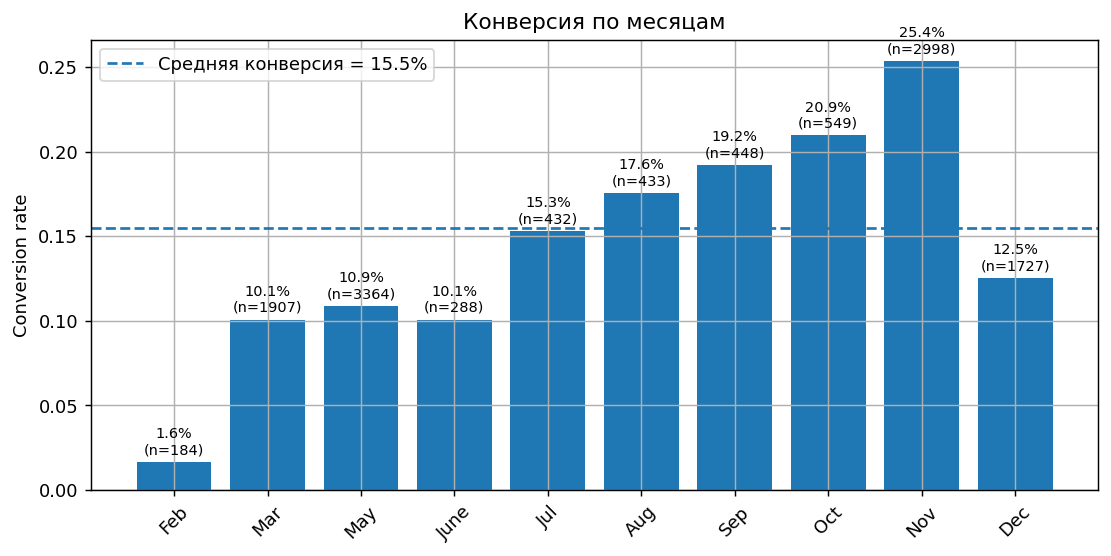

,Month,conversion_rate,sessions
0,Feb,0.0163,184
1,Mar,0.1007,1907
2,May,0.1085,3364
3,June,0.1007,288
4,Jul,0.1528,432
5,Aug,0.1755,433
6,Sep,0.1920,448
7,Oct,0.2095,549
8,Nov,0.2535,2998
9,Dec,0.1251,1727


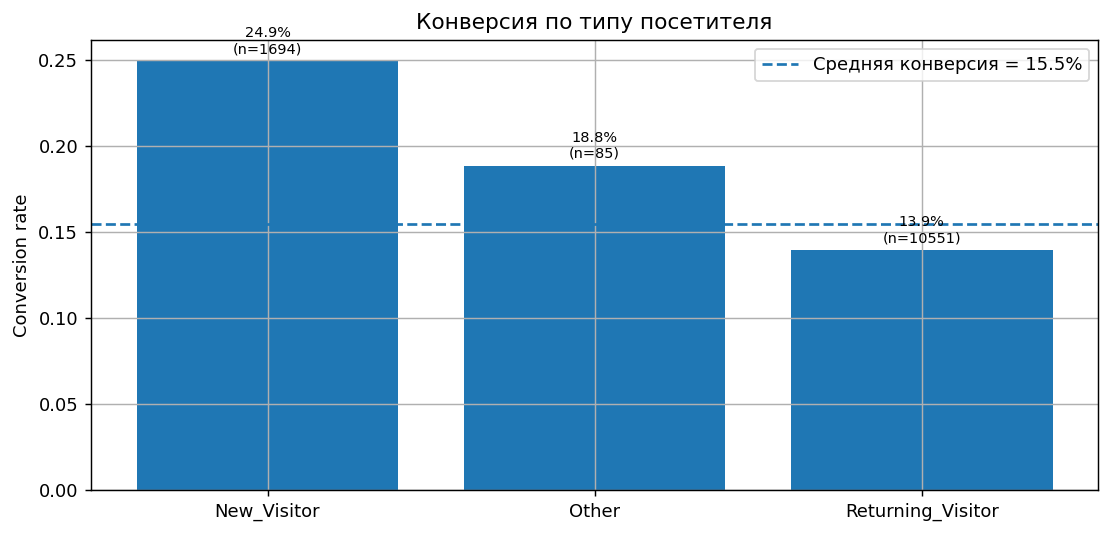

,VisitorType,conversion_rate,sessions
0,New_Visitor,0.2491,1694
1,Other,0.1882,85
2,Returning_Visitor,0.1393,10551


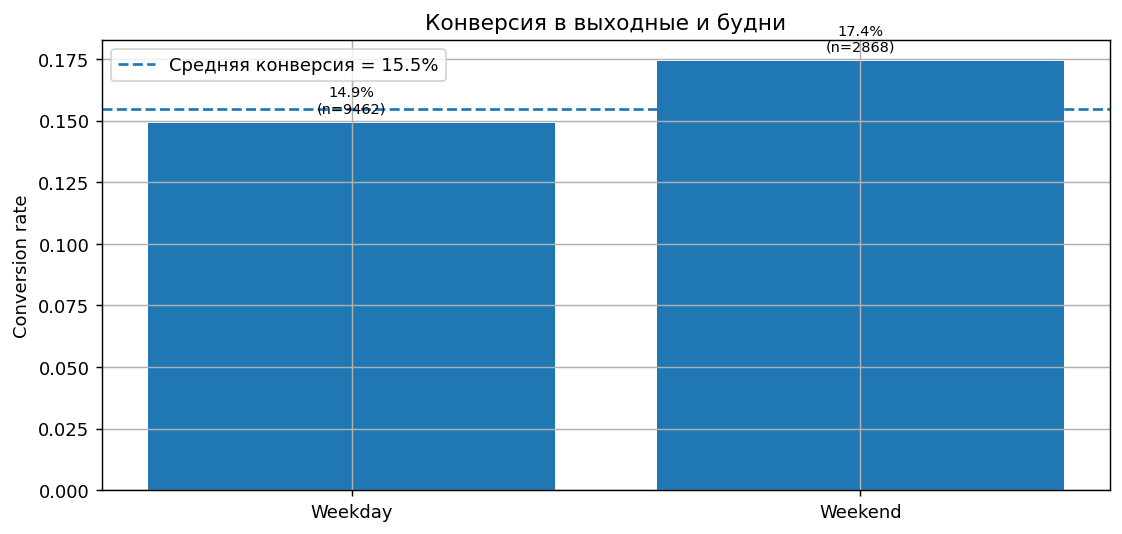

,WeekendLabel,conversion_rate,sessions
0,Weekday,0.1489,9462
1,Weekend,0.1740,2868


In [13]:

month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_summary = plot_rate_by_category(
    df,
    col="Month",
    title="Конверсия по месяцам",
    order=month_order,
    rotation=45
)

visitor_summary = plot_rate_by_category(
    df,
    col="VisitorType",
    title="Конверсия по типу посетителя",
    sort_by_rate=True
)

weekend_frame = df.assign(WeekendLabel=np.where(df["Weekend"], "Weekend", "Weekday"))
weekend_summary = plot_rate_by_category(
    weekend_frame,
    col="WeekendLabel",
    title="Конверсия в выходные и будни"
)



### 4.7. Трафик и регион


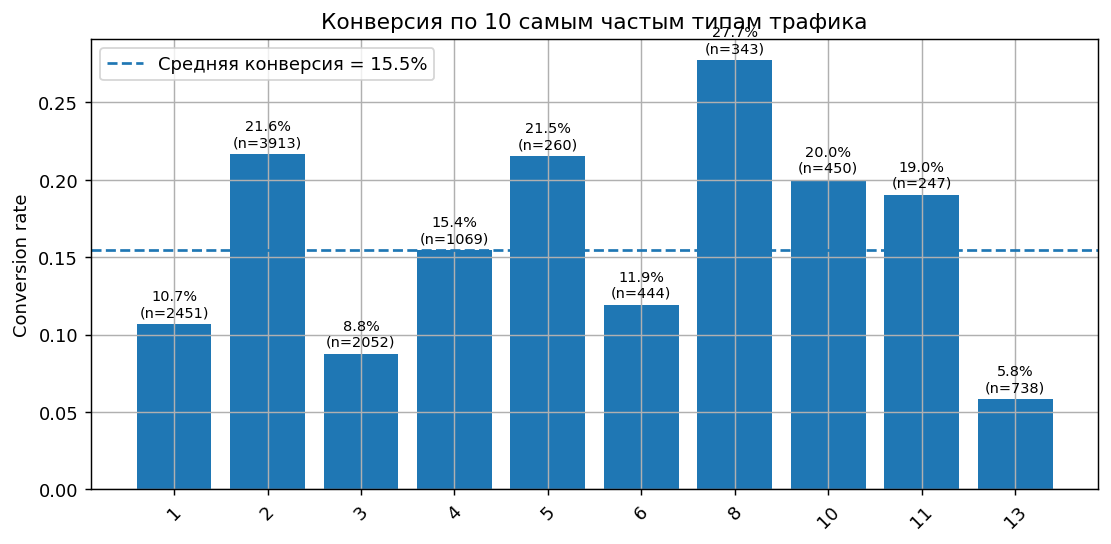

,TrafficType,conversion_rate,sessions
0,1,0.1069,2451
1,2,0.2165,3913
2,3,0.0877,2052
3,4,0.1543,1069
4,5,0.2154,260
5,6,0.1194,444
6,8,0.2770,343
7,10,0.2000,450
8,11,0.1903,247
9,13,0.0583,738


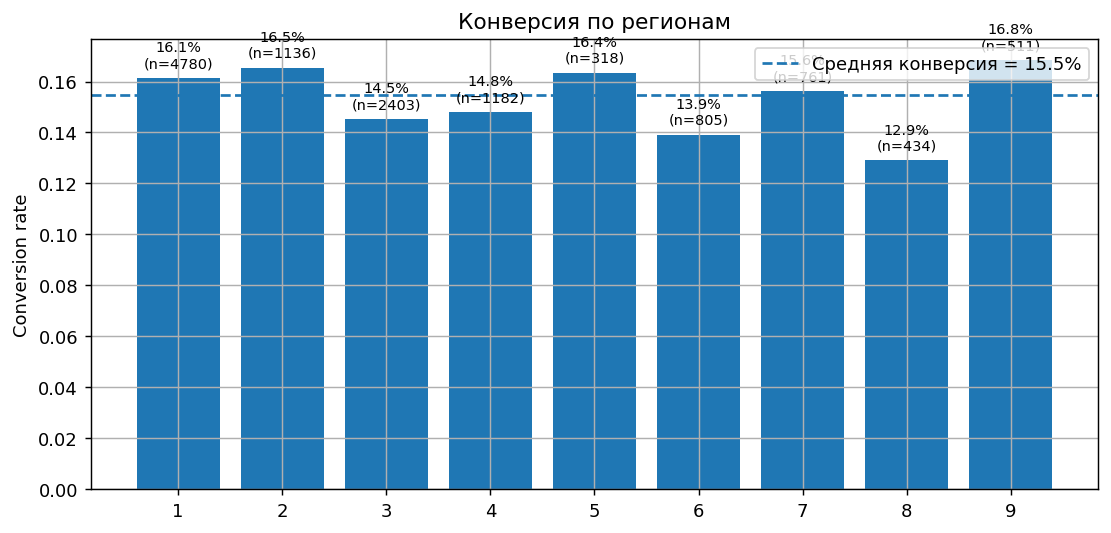

,Region,conversion_rate,sessions
0,1,0.1613,4780
1,2,0.1655,1136
2,3,0.1452,2403
3,4,0.1481,1182
4,5,0.1635,318
5,6,0.1391,805
6,7,0.1564,761
7,8,0.1290,434
8,9,0.1683,511


In [14]:

traffic_summary = plot_rate_by_category(
    df,
    col="TrafficType",
    title="Конверсия по 10 самым частым типам трафика",
    top_n=10,
    rotation=45
)

region_summary = plot_rate_by_category(
    df,
    col="Region",
    title="Конверсия по регионам",
    sort_by_rate=False
)



## Выводы по EDA

**Что подтверждается на данных:**

- **Product-related behavior** действительно тесно связано с покупкой: чем больше товарных страниц просмотрено и чем дольше пользователь на них остаётся, тем выше conversion rate.
- **ExitRates** и **BounceRates** показывают обратную зависимость: рост этих метрик обычно сопровождается снижением вероятности покупки.
- **PageValues** — один из самых сильных индикаторов будущей покупки, что логично и хорошо согласуется с бизнес-смыслом признака.
- У **новых посетителей** конверсия выше, чем у returning visitors.
- **Ноябрь** выглядит одним из лучших месяцев по конверсии, а **выходные** в среднем чуть сильнее будней.
- **Region**, **Browser** и **OperatingSystems** выглядят значительно слабее, чем поведенческие признаки.

> Иными словами, главный сигнал идёт не столько от “технических” атрибутов пользователя, сколько от его **поведения внутри сессии**.



## 5. Подготовка данных к моделированию

Предобработка данныех реализована через `ColumnTransformer` и `Pipeline`.


In [15]:

X = df.drop(columns="Revenue")
y = df["Revenue"].astype(int)

# 60% train / 20% validation / 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=SEED
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "conversion_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

display(split_summary.round(4))

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

Xtr = preprocessor.fit_transform(X_train)
Xva = preprocessor.transform(X_valid)

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")
print(f"Размер матрицы признаков после OHE: {Xtr.shape}")


,split,rows,conversion_rate
0,train,7398,0.1548
1,validation,2466,0.1545
2,test,2466,0.1549


Числовых признаков: 14
Категориальных признаков: 3
Размер матрицы признаков после OHE: (7398, 29)


In [16]:

def evaluate_classifier(model, X_data, y_true):
    proba = model.predict_proba(X_data)[:, 1]
    pred = model.predict(X_data)
    return {
        "ROC AUC": roc_auc_score(y_true, proba),
        "PR AUC": average_precision_score(y_true, proba),
        "Accuracy": accuracy_score(y_true, pred)
    }



## 6. Бейзлайн: DummyClassifier

Это полезная точка отсчёта.  
Если даже очень простой бейзлайн показывает высокую `accuracy`, но плохой `ROC AUC`, значит: на несбалансированных данных смотреть только на accuracy нельзя.


In [17]:

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(Xtr, y_train)

dummy_valid = evaluate_classifier(dummy, Xva, y_valid)
display(pd.DataFrame([dummy_valid], index=["DummyClassifier"]).round(4))


,ROC AUC,PR AUC,Accuracy
DummyClassifier,0.5,0.1545,0.8455



## 7. RandomForest — первый сильный бейзлайн

`RandomForest` даёт хорошую и понятную отправную точку.  

In [18]:

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(Xtr, y_train)
rf_valid = evaluate_classifier(rf, Xva, y_valid)
display(pd.DataFrame([rf_valid], index=["RandomForest (validation)"]).round(4))


,ROC AUC,PR AUC,Accuracy
RandomForest (validation),0.9323,0.7337,0.8978



## 8. Базовый XGBoost

Сначала обучим разумный базовый вариант, а затем слегка потюним гиперпараметры.


In [19]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=SEED,
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_alpha=0.0,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=scale_pos_weight,
    n_jobs=4,
    early_stopping_rounds=30
)

xgb_base.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_valid)],
    verbose=False
)

xgb_base_valid = evaluate_classifier(xgb_base, Xva, y_valid)
display(pd.DataFrame([xgb_base_valid], index=["XGBoost baseline (validation)"]).round(4))
print(f"Best boosting iteration: {xgb_base.best_iteration}")


,ROC AUC,PR AUC,Accuracy
XGBoost baseline (validation),0.9327,0.7291,0.8646


Best boosting iteration: 61



## 9. Компактный тюнинг XGBoost

Делаю **облегчённый воспроизводимый random search** по ключевым гиперпараметрам:

- строим пространство параметров;
- обучаем модель на train;
- выбираем лучшие параметры по `ROC AUC` на validation.


In [20]:

def sample_xgb_params():
    return {
        "max_depth": random.randint(3, 10),
        "learning_rate": random.choice([0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]),
        "reg_alpha": random.choice([0, 0.1, 0.5, 1, 2, 5]),
        "reg_lambda": random.choice([1, 2, 5, 10, 15]),
        "colsample_bytree": random.choice([0.6, 0.7, 0.8, 0.9, 1.0]),
        "min_child_weight": random.choice([1, 2, 3, 5, 7, 10]),
        "subsample": random.choice([0.6, 0.7, 0.8, 0.9, 1.0]),
        "max_delta_step": random.choice([0, 1, 3, 5, 7]),
        "n_estimators": random.choice([200, 300, 400, 500, 700]),
        "scale_pos_weight": random.choice([1, 2, 3, 4, 5, 6]),
        "gamma": random.choice([0, 0.5, 1, 3, 5, 7]),
    }

trials = []
best_auc = -1
best_params = None

for trial in range(12):
    params = sample_xgb_params()

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=SEED,
        tree_method="hist",
        n_jobs=4,
        early_stopping_rounds=30,
        **params
    )

    model.fit(
        Xtr, y_train,
        eval_set=[(Xva, y_valid)],
        verbose=False
    )

    metrics = evaluate_classifier(model, Xva, y_valid)

    row = {
        "trial": trial + 1,
        "best_iteration": int(model.best_iteration),
        **params,
        **metrics
    }
    trials.append(row)

    if metrics["ROC AUC"] > best_auc:
        best_auc = metrics["ROC AUC"]
        best_params = params.copy()
        best_params["n_estimators"] = int(model.best_iteration) + 1

trials_df = pd.DataFrame(trials).sort_values("ROC AUC", ascending=False).reset_index(drop=True)

display(trials_df.head(10).round(4))
print("Best params for final model:")
print(best_params)


,trial,best_iteration,max_depth,learning_rate,reg_alpha,reg_lambda,colsample_bytree,min_child_weight,subsample,max_delta_step,n_estimators,scale_pos_weight,gamma,ROC AUC,PR AUC,Accuracy
0,5,120,10,0.02,1.0,1,1.0,3,1.0,3,700,2,7.0,0.9357,0.7473,0.9019
1,12,22,5,0.15,2.0,1,0.9,5,1.0,5,700,3,5.0,0.9353,0.7387,0.8917
2,11,17,9,0.15,0.5,2,0.7,7,0.9,0,200,1,0.5,0.9348,0.7322,0.8986
3,9,112,3,0.10,1.0,5,0.6,2,1.0,3,300,6,3.0,0.9343,0.7346,0.8451
4,8,200,6,0.03,1.0,10,0.8,10,1.0,1,400,1,0.5,0.9343,0.7409,0.8970
5,4,25,6,0.10,0.0,1,0.9,1,0.8,3,700,3,0.0,0.9334,0.7381,0.8913
6,3,87,9,0.05,1.0,15,0.8,1,0.7,5,400,3,0.5,0.9330,0.7313,0.8933
7,10,31,9,0.20,0.1,5,0.7,2,1.0,7,400,6,5.0,0.9314,0.7312,0.8658
8,2,13,9,0.01,0.0,1,0.7,2,1.0,7,200,5,0.5,0.9301,0.7119,0.8950
9,6,11,4,0.01,5.0,2,0.8,1,0.7,0,500,3,3.0,0.9291,0.7028,0.8455


Best params for final model:
{'max_depth': 10, 'learning_rate': 0.02, 'reg_alpha': 1, 'reg_lambda': 1, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'subsample': 1.0, 'max_delta_step': 3, 'n_estimators': 121, 'scale_pos_weight': 2, 'gamma': 7}



### Сравнение моделей на validation


In [21]:

validation_comparison = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_valid},
    {"model": "RandomForest", **rf_valid},
    {"model": "XGBoost baseline", **xgb_base_valid},
    {"model": "XGBoost tuned (best validation trial)", "ROC AUC": trials_df.loc[0, "ROC AUC"], "PR AUC": trials_df.loc[0, "PR AUC"], "Accuracy": trials_df.loc[0, "Accuracy"]}
])

display(validation_comparison.sort_values("ROC AUC", ascending=False).round(4))


,model,ROC AUC,PR AUC,Accuracy
3,XGBoost tuned (best validation trial),0.9357,0.7473,0.9019
2,XGBoost baseline,0.9327,0.7291,0.8646
1,RandomForest,0.9323,0.7337,0.8978
0,DummyClassifier,0.5000,0.1545,0.8455



## 10. Финальная модель и честная оценка на holdout-test

Теперь переобучим модели на всём `train + validation` и один раз оценим их на `test`.  
Это и будет основной результат проекта.


In [22]:

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

X_train_full_proc = preprocessor_final.fit_transform(X_train_full)
X_test_proc = preprocessor_final.transform(X_test)

dummy_final = DummyClassifier(strategy="most_frequent")
dummy_final.fit(X_train_full_proc, y_train_full)

rf_final = RandomForestClassifier(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_final.fit(X_train_full_proc, y_train_full)

xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=SEED,
    tree_method="hist",
    n_jobs=4,
    **best_params
)
xgb_final.fit(X_train_full_proc, y_train_full, verbose=False)

test_comparison = pd.DataFrame([
    {"model": "DummyClassifier", **evaluate_classifier(dummy_final, X_test_proc, y_test)},
    {"model": "RandomForest", **evaluate_classifier(rf_final, X_test_proc, y_test)},
    {"model": "XGBoost tuned", **evaluate_classifier(xgb_final, X_test_proc, y_test)}
])

display(test_comparison.sort_values("ROC AUC", ascending=False).round(4))


,model,ROC AUC,PR AUC,Accuracy
2,XGBoost tuned,0.9300,0.7476,0.8925
1,RandomForest,0.9227,0.7287,0.8974
0,DummyClassifier,0.5000,0.1549,0.8451



### ROC-кривые на тесте


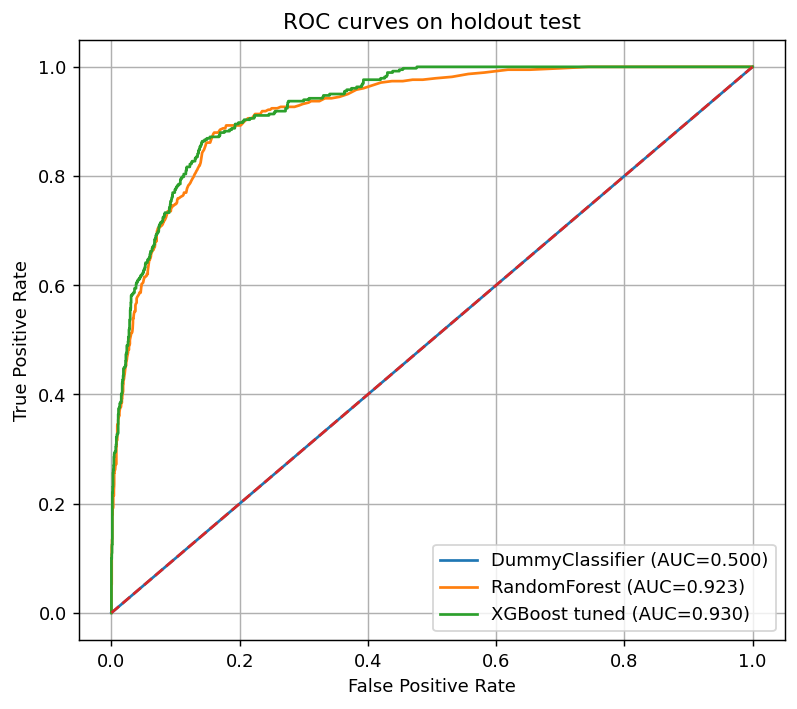

In [23]:

rf_proba = rf_final.predict_proba(X_test_proc)[:, 1]
xgb_proba = xgb_final.predict_proba(X_test_proc)[:, 1]
dummy_proba = dummy_final.predict_proba(X_test_proc)[:, 1]

curves = {
    "DummyClassifier": dummy_proba,
    "RandomForest": rf_proba,
    "XGBoost tuned": xgb_proba
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in curves.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves on holdout test")
ax.legend()
plt.show()



## 11. Интерпретация: какие признаки важнее всего для XGBoost


,feature,importance
9,PageValues,0.5534
7,Month,0.2029
15,VisitorType,0.0414
2,BounceRates,0.0223
11,ProductRelated_Duration,0.0194
10,ProductRelated,0.0191
0,Administrative,0.0173
4,ExitRates,0.0164
1,Administrative_Duration,0.0152
14,TrafficType,0.0125


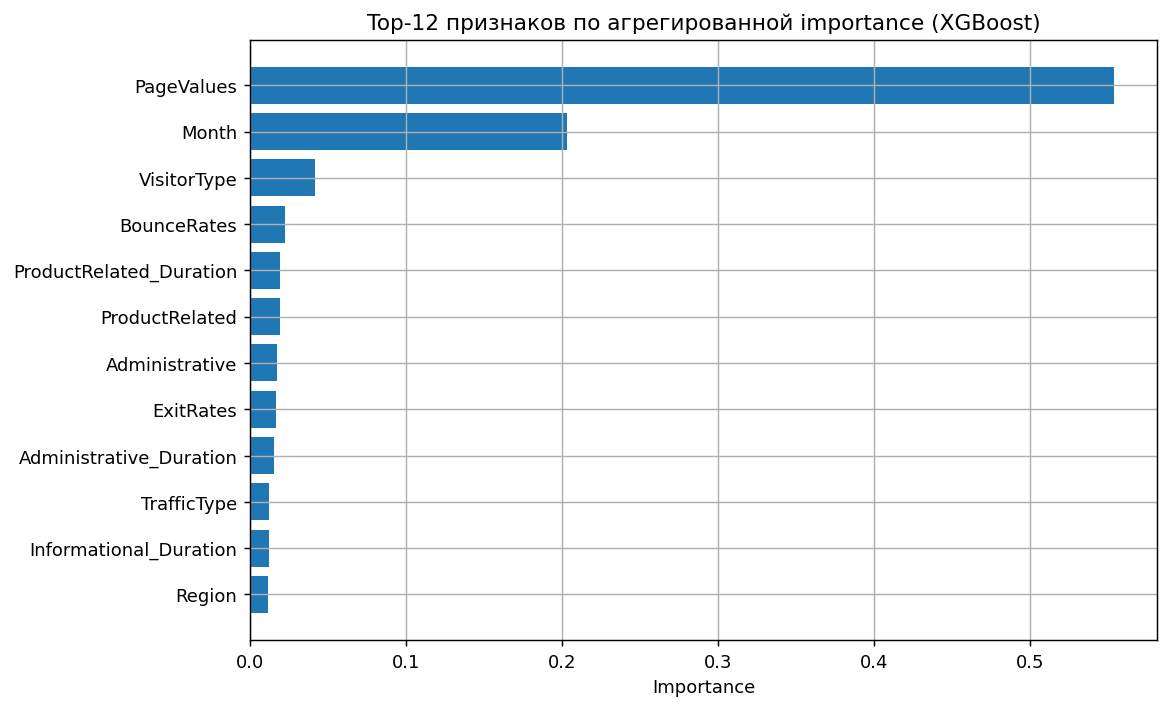

In [24]:

encoded_feature_names = preprocessor_final.get_feature_names_out()
importances = xgb_final.feature_importances_
raw_features = X.columns.tolist()

def map_encoded_to_raw(feature_name):
    cleaned = feature_name.split("__", 1)[1] if "__" in feature_name else feature_name
    for raw in sorted(raw_features, key=len, reverse=True):
        if cleaned == raw or cleaned.startswith(raw + "_"):
            return raw
    return cleaned

importance_df = pd.DataFrame({
    "encoded_feature": encoded_feature_names,
    "importance": importances
})
importance_df["feature"] = importance_df["encoded_feature"].map(map_encoded_to_raw)

grouped_importance = (
    importance_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(grouped_importance.head(15).round(4))

fig, ax = plt.subplots(figsize=(9, 6))
top_imp = grouped_importance.head(12).sort_values("importance")
ax.barh(top_imp["feature"], top_imp["importance"])
ax.set_title("Top-12 признаков по агрегированной importance (XGBoost)")
ax.set_xlabel("Importance")
plt.show()



## 12. Как модель может использоваться в бизнесе: lift по децилям

Для CRM и performance-маркетинга важны не только средние метрики модели, но и ответ на вопрос:  
**насколько хорошо модель умеет вытаскивать самых “горячих” пользователей наверх рейтинга?**


,decile,conversion_rate,sessions
0,9,0.7773,247
1,8,0.4146,246
2,7,0.1822,247
3,6,0.0813,246
4,5,0.0567,247
5,4,0.0369,244
6,3,0.0000,237
7,2,0.0000,250
8,1,0.0000,502


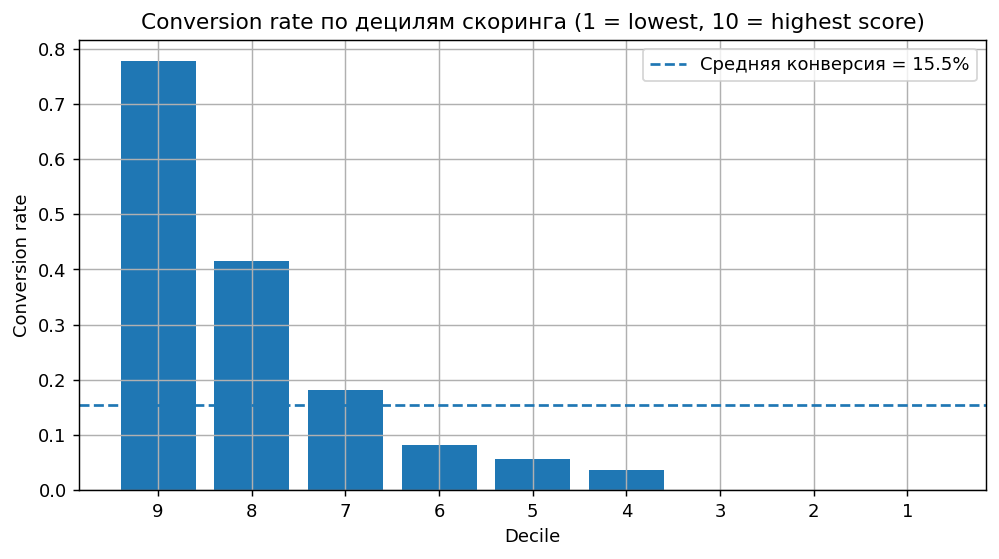

In [25]:

scored = pd.DataFrame({
    "actual": y_test.values,
    "score": xgb_proba
})

scored["decile"] = pd.qcut(scored["score"], 10, labels=False, duplicates="drop") + 1

lift_table = (
    scored.groupby("decile")
    .agg(conversion_rate=("actual", "mean"), sessions=("actual", "size"))
    .sort_index(ascending=False)
    .reset_index()
)

display(lift_table.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(lift_table["decile"].astype(str), lift_table["conversion_rate"])
ax.axhline(df["Revenue"].mean(), linestyle="--", label=f"Средняя конверсия = {df['Revenue'].mean():.1%}")
ax.set_title("Conversion rate по децилям скоринга (1 = lowest, 10 = highest score)")
ax.set_xlabel("Decile")
ax.set_ylabel("Conversion rate")
ax.legend()
plt.show()



## 13. Финальные выводы и рекомендации

### Что получилось

- На несбалансированных данных **accuracy сама по себе бесполезна**: даже наивный классификатор может показать высокий процент “правильных” ответов просто за счёт класса большинства.
- Уже **RandomForest** даёт сильный результат и служит хорошим baseline.
- **XGBoost** после тюнинга стабильно оказывается лучшей моделью в этом проекте.
- На holdout-test модель показывает **ROC AUC около 0.93**.

### Что это значит для бизнеса

1. **Главный драйвер конверсии — вовлечённость в товарный каталог.**  
   Чем глубже пользователь уходит в карточки товаров и чем дольше там остаётся, тем выше шанс покупки.

2. **Exit Rate и Bounce Rate — тревожные сигналы.**  
   Если эти метрики высокие, стоит проверять:
   - релевантность входного трафика,
   - скорость загрузки и UX посадочных страниц,
   - качество навигации и карточек товара.

3. **Новых посетителей нельзя недооценивать.**  
   В данных они показывают более высокий conversion rate, чем returning users — это аргумент в пользу масштабирования качественного acquisition-трафика.

4. **Скоринг можно встроить в маркетинг и CRM.**  
   Пользователям с высокой предсказанной вероятностью конверсии можно:
   - показывать персональные офферы,
   - триггерить скидку после достижения определённого времени на product-related pages,
   - приоритизировать remarketing и персонализацию.

In [26]:

import sklearn
import xgboost
versions = pd.DataFrame({
    "package": ["pandas", "numpy", "scikit-learn", "xgboost"],
    "version": [pd.__version__, np.__version__, sklearn.__version__, xgboost.__version__]
})
display(versions)


,package,version
0,pandas,2.2.3
1,numpy,2.2.6
2,scikit-learn,1.6.1
3,xgboost,3.2.0
